In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../data/raw/insurance.csv')

# Display the first 5 rows
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Check data types and missing values
print("Dataset Information:")
display(df.info())

# Summary statistics for numerical columns
print("\nSummary Statistics:")
display(df.describe())

# Summary statistics for categorical columns
print("\nCategorical Features:")
display(df.describe(include=['object']))

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


None


Summary Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Categorical Features:


C:\Users\aybek\AppData\Local\Temp\ipykernel_2516\4280852243.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']))


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


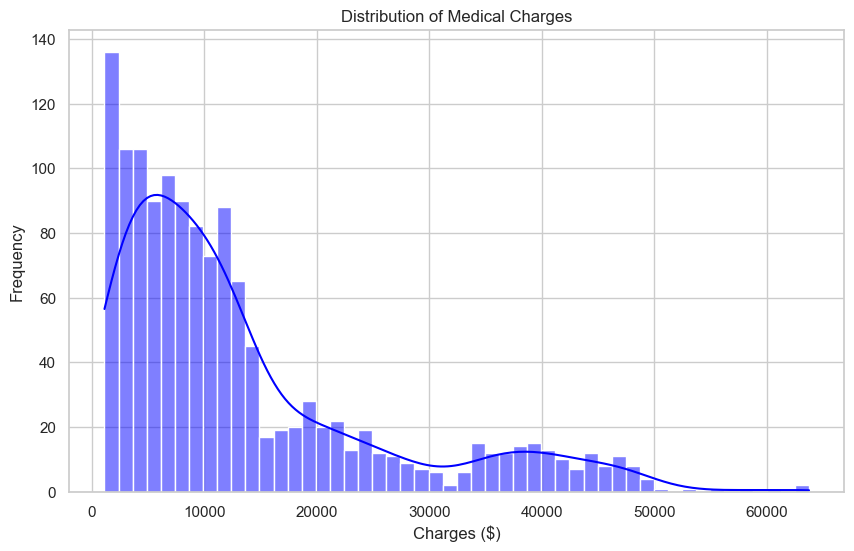

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, bins=50, color='blue')
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

C:\Users\aybek\AppData\Local\Temp\ipykernel_2516\2162440522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


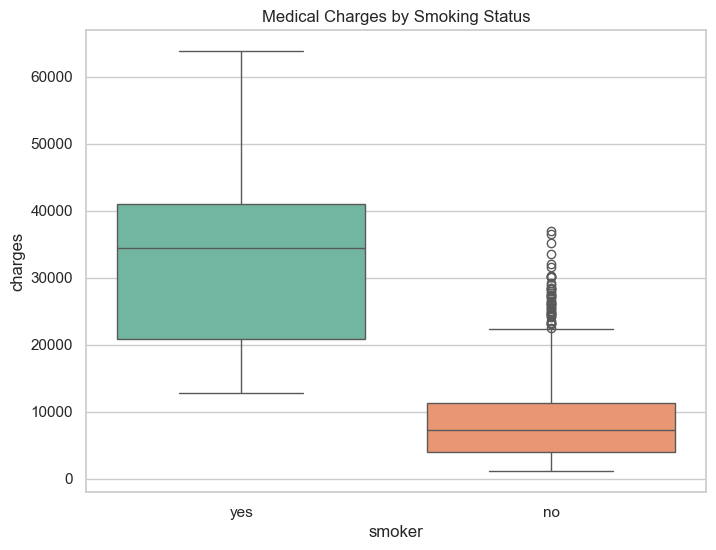

Average charges based on smoking status:


smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Medical Charges by Smoking Status')
plt.show()

# Average charges
print("Average charges based on smoking status:")
display(df.groupby('smoker')['charges'].mean())

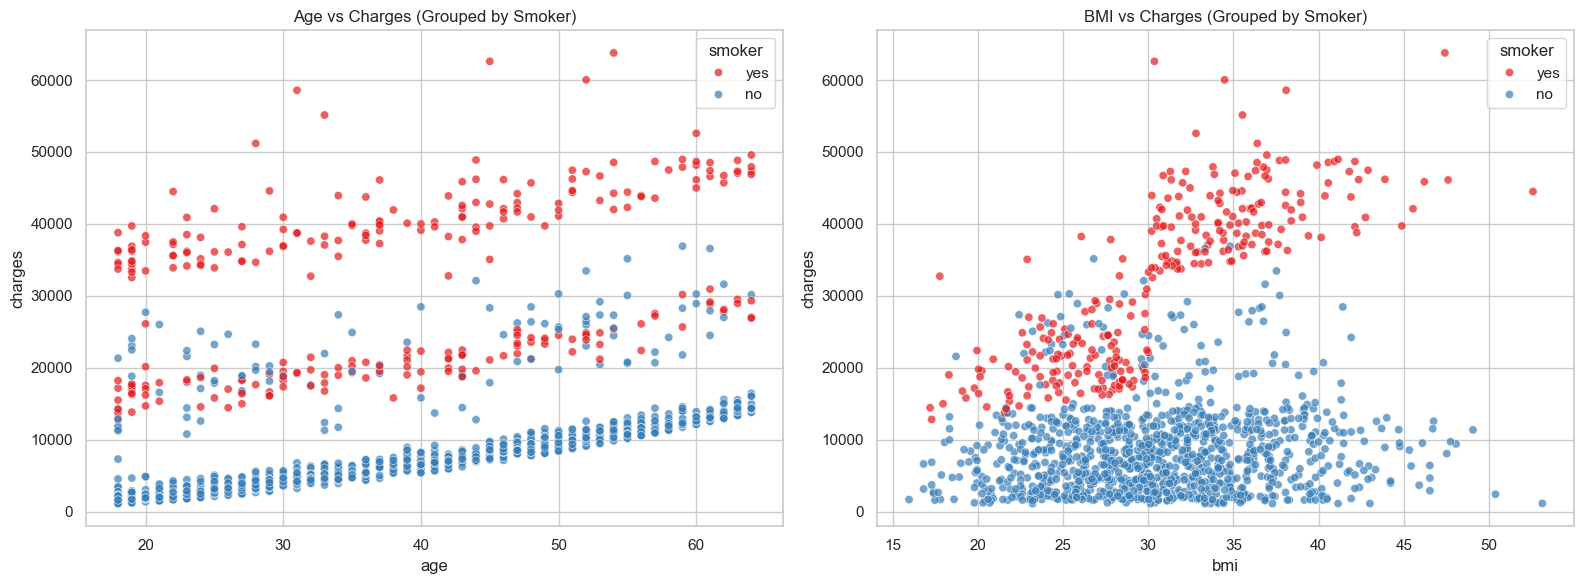

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs Charges by Smoker
sns.scatterplot(ax=axes[0], x='age', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
axes[0].set_title('Age vs Charges (Grouped by Smoker)')

# BMI vs Charges by Smoker
sns.scatterplot(ax=axes[1], x='bmi', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
axes[1].set_title('BMI vs Charges (Grouped by Smoker)')

plt.tight_layout()
plt.show()

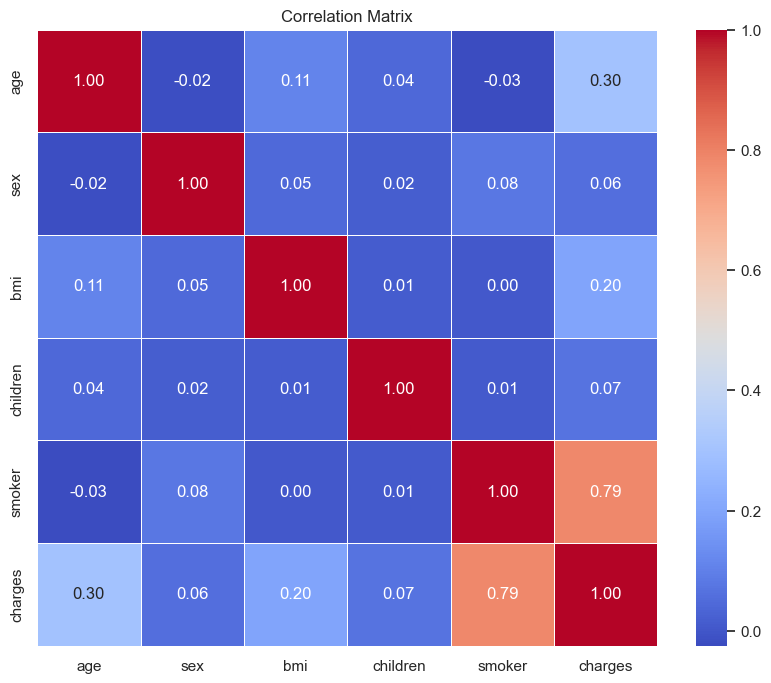

In [6]:
# Create a copy for correlation mapping
df_corr = df.copy()

# Map categorical variables to numeric for correlation
df_corr['sex'] = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()